# 04 — Red Neuronal Multicapa (MLP)

**Caso de uso:** Predicción de Diagnóstico de Cáncer  
**Asignatura:** Inteligencia Artificial — UAX 2025/2026  
**Autor:** Álvaro Santamaría Antón

## Tarea principal del proyecto

> *"El diseño, entrenamiento y validación de la Red Neuronal Multicapa (MLP) constituye el núcleo técnico del trabajo."* — Enunciado del caso

## Arquitectura (definida en `src/model_mlp.py`)

- **Entrada**: 21 features
- **3 capas ocultas**: 256 → 128 → 64 neuronas
- Cada capa oculta: `Dense → BatchNormalization → ReLU → Dropout`
- **Dropout**: 0.25 / 0.25 / 0.20
- **Salida**: 1 neurona con sigmoid
- **Total**: 48.641 parámetros (~46.913 según el PDF)

## Configuración del entrenamiento

- **Optimizador**: Adam (lr inicial = 1e-3)
- **Loss**: binary_crossentropy
- **Métricas**: accuracy, AUC, precision, recall
- **Class weights**: balanceados (0.62 / 2.59) para gestionar el 80/20
- **Callbacks**:
  - `EarlyStopping(patience=12)` — para si `val_loss` no mejora en 12 épocas
  - `ReduceLROnPlateau(factor=0.5, patience=6)` — reduce el lr a la mitad si se estanca
- **Batch size**: 64
- **Epochs máximas**: 100 (el EarlyStopping suele cortar antes)

## Procedimiento de evaluación

1. Entrenar con train + validar en val cada época
2. Pintar curvas de loss y accuracy por época
3. Evaluar en val con threshold=0.5 (referencia)
4. **Optimizar threshold en val** maximizando F1 (rango [0.10, 0.90], paso 0.01)
5. Aplicar el threshold óptimo **una sola vez** al final

## Imports y carga de datos

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import load_splits
from src.model_mlp import build_mlp, get_callbacks, set_seeds
from src.evaluation import (
    evaluate_model_full,
    evaluate_with_threshold,
    find_best_threshold,
    plot_confusion_matrix,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR  = PROJECT_ROOT / "models"

# Cargar datos procesados
print("Cargando datos procesados...")
data = load_splits()

X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]
feature_names    = data["feature_names"]
class_weights    = data["class_weights"]

print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  Class weights: {class_weights}")

Cargando datos procesados...
  X_train: (30000, 21)
  X_val:   (10000, 21)
  X_test:  (10001, 21)
  Class weights: {0: 0.6194763360039647, 1: 2.5924645696508812}


## Construcción del modelo

In [2]:
# Fijar semillas para reproducibilidad
set_seeds(42)

# Construir la red
model = build_mlp(input_dim=X_train.shape[1])

print("Arquitectura del modelo:\n")
model.summary()

Arquitectura del modelo:



Model: "MLP_cancer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,641 (190.00 KB)

 Trainable params: 47,745 (186.50 KB)

 Non-trainable params: 896 (3.50 KB)

## Entrenamiento

In [3]:
# Configuración del entrenamiento
EPOCHS = 100
BATCH_SIZE = 64

# Callbacks (EarlyStopping + ReduceLROnPlateau)
cbs = get_callbacks(
    monitor="val_loss",
    patience_early=12,
    patience_lr=6,
    factor_lr=0.5,
    verbose=1,
)

print("Iniciando entrenamiento...\n")
print(f"  Epochs máximas: {EPOCHS}")
print(f"  Batch size:     {BATCH_SIZE}")
print(f"  Class weights:  {class_weights}")
print(f"  Callbacks:      EarlyStopping (patience=12), ReduceLROnPlateau (factor=0.5, patience=6)")
print()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=cbs,
    verbose=1,
)

print(f"\nEntrenamiento terminado tras {len(history.history['loss'])} épocas.")

Iniciando entrenamiento...

  Epochs máximas: 100
  Batch size:     64
  Class weights:  {0: 0.6194763360039647, 1: 2.5924645696508812}
  Callbacks:      EarlyStopping (patience=12), ReduceLROnPlateau (factor=0.5, patience=6)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7014 - auc: 0.7850 - loss: 0.5657 - precision: 0.3638 - recall: 0.7326 - val_accuracy: 0.7056 - val_auc: 0.8166 - val_loss: 0.5563 - val_precision: 0.3735 - val_recall: 0.7771 - learning_rate: 0.0010
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7290 - auc: 0.8121 - loss: 0.5313 - precision: 0.3945 - recall: 0.7575 - val_accuracy: 0.7095 - val_auc: 0.8200 - val_loss: 0.5413 - val_precision: 0.3773 - val_recall: 0.7781 - learning_rate: 0.0010
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7324 - auc: 0.8195 - loss: 0.5217 - precision: 0.3989 - recall: 0.7651 - val_accuracy: 0.7282 - val_auc: 0.8199 - val_loss: 0.5202 - val_precision: 0.3939 - val_recall: 0.7

## Curvas de aprendizaje

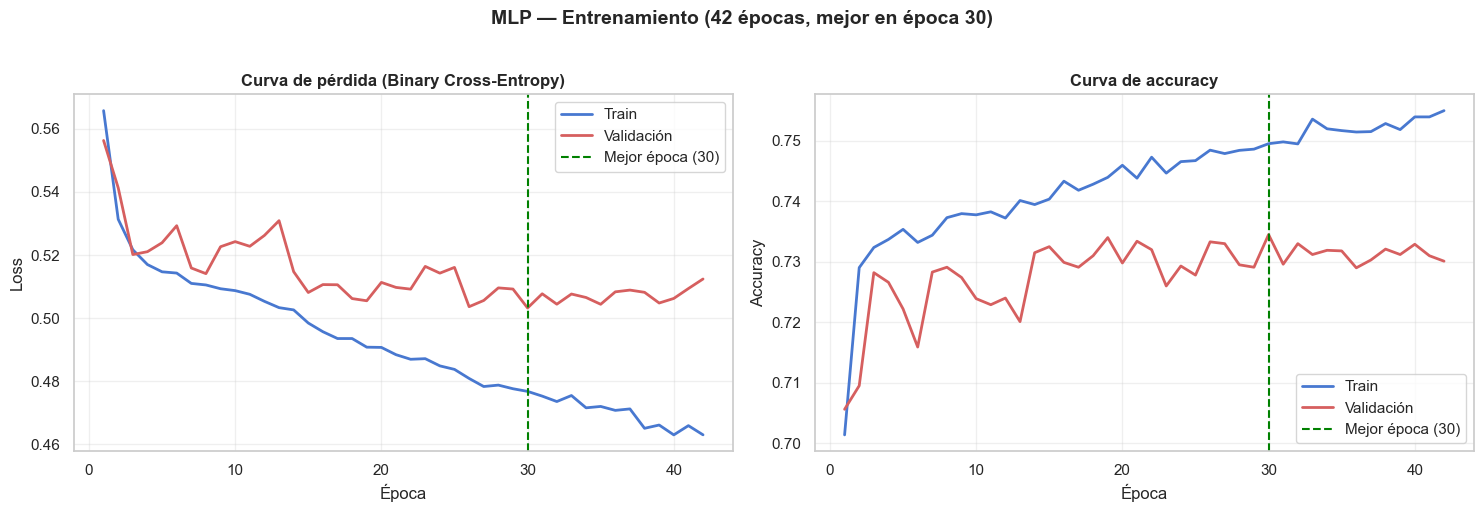


Diagnóstico:
  Épocas entrenadas:    42
  Mejor época:          30 (val_loss = 0.5032)
  Loss train final:     0.4630
  Loss val final:       0.5124
  Accuracy train final: 0.7550
  Accuracy val final:   0.7301

  ✓ Gap train/val = +0.0264 → entrenamiento sano (sin overfit ni underfit)


In [4]:
# === CURVAS DE LOSS Y ACCURACY POR ÉPOCA ===
hist = history.history
n_epochs = len(hist["loss"])
epochs = range(1, n_epochs + 1)

# Encontrar la mejor época (mínimo val_loss)
best_epoch = np.argmin(hist["val_loss"]) + 1
best_val_loss = min(hist["val_loss"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- LOSS ---
axes[0].plot(epochs, hist["loss"], "b-", linewidth=2, label="Train")
axes[0].plot(epochs, hist["val_loss"], "r-", linewidth=2, label="Validación")
axes[0].axvline(best_epoch, color="green", linestyle="--", linewidth=1.5,
                label=f"Mejor época ({best_epoch})")
axes[0].set_title("Curva de pérdida (Binary Cross-Entropy)", fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

# --- ACCURACY ---
axes[1].plot(epochs, hist["accuracy"], "b-", linewidth=2, label="Train")
axes[1].plot(epochs, hist["val_accuracy"], "r-", linewidth=2, label="Validación")
axes[1].axvline(best_epoch, color="green", linestyle="--", linewidth=1.5,
                label=f"Mejor época ({best_epoch})")
axes[1].set_title("Curva de accuracy", fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.suptitle(f"MLP — Entrenamiento ({n_epochs} épocas, mejor en época {best_epoch})",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "17_mlp_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nDiagnóstico:")
print(f"  Épocas entrenadas:    {n_epochs}")
print(f"  Mejor época:          {best_epoch} (val_loss = {best_val_loss:.4f})")
print(f"  Loss train final:     {hist['loss'][-1]:.4f}")
print(f"  Loss val final:       {hist['val_loss'][-1]:.4f}")
print(f"  Accuracy train final: {hist['accuracy'][-1]:.4f}")
print(f"  Accuracy val final:   {hist['val_accuracy'][-1]:.4f}")

# Diagnóstico over/underfitting
gap = hist['val_loss'][best_epoch-1] - hist['loss'][best_epoch-1]
if abs(gap) < 0.05:
    print(f"\n  ✓ Gap train/val = {gap:+.4f} → entrenamiento sano (sin overfit ni underfit)")
elif gap > 0.05:
    print(f"\n  ⚠️  Gap train/val = {gap:+.4f} → ligero overfit (val > train)")
else:
    print(f"\n  ⚠️  Gap train/val = {gap:+.4f} → posible underfit (train > val)")

## Evaluación inicial en val con threshold=0.5

In [5]:
# === EVALUACIÓN EN VALIDACIÓN CON THRESHOLD = 0.5 (referencia) ===
metrics_val_default = evaluate_model_full(model, X_val, y_val, threshold=0.5)

print("=" * 60)
print("  MLP — Métricas en VALIDACIÓN (threshold = 0.5)")
print("=" * 60)
print(f"  Precisión : {metrics_val_default['precision']:.4f}")
print(f"  Recall    : {metrics_val_default['recall']:.4f}")
print(f"  F1-Score  : {metrics_val_default['f1']:.4f}")
print(f"  AUC-ROC   : {metrics_val_default['auc_roc']:.4f}")
print(f"  Accuracy  : {metrics_val_default['accuracy']:.4f}")

  MLP — Métricas en VALIDACIÓN (threshold = 0.5)
  Precisión : 0.3980
  Recall    : 0.7346
  F1-Score  : 0.5163
  AUC-ROC   : 0.8137
  Accuracy  : 0.7345


## Optimización del umbral en validación

Umbral óptimo (maximizando F1 en val): 0.68
F1-Score con ese umbral:                0.5409

Mejora respecto a threshold=0.5: +0.0246


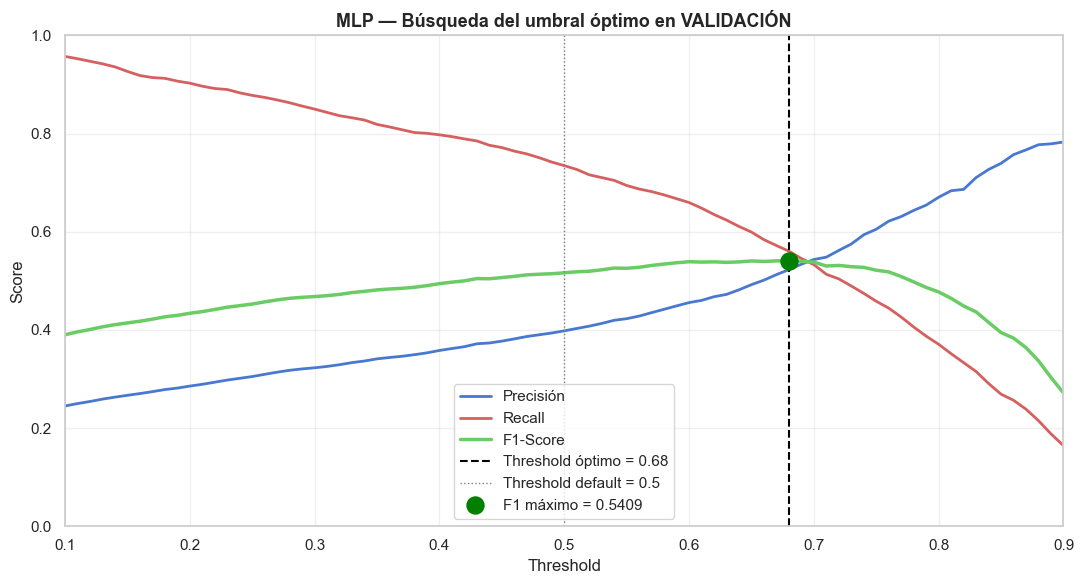

In [6]:
# === OPTIMIZACIÓN DEL UMBRAL (procedimiento del PDF) ===
# IMPORTANTE: se hace SOLO sobre validación, nunca sobre test.

y_proba_val = metrics_val_default["y_proba"]

threshold_search = find_best_threshold(
    y_true=y_val,
    y_proba=y_proba_val,
    metric="f1",
    thresholds=np.arange(0.10, 0.91, 0.01),
)

best_t = threshold_search["best_threshold"]
best_f1 = threshold_search["best_score"]
results_df = threshold_search["all_results"]

print(f"Umbral óptimo (maximizando F1 en val): {best_t:.2f}")
print(f"F1-Score con ese umbral:                {best_f1:.4f}")
print(f"\nMejora respecto a threshold=0.5: {best_f1 - metrics_val_default['f1']:+.4f}")

# Visualización: cómo varían las métricas con el umbral
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(results_df["threshold"], results_df["precision"], "b-", linewidth=2, label="Precisión")
ax.plot(results_df["threshold"], results_df["recall"], "r-", linewidth=2, label="Recall")
ax.plot(results_df["threshold"], results_df["f1"], "g-", linewidth=2.5, label="F1-Score")
ax.axvline(best_t, color="black", linestyle="--", linewidth=1.5,
           label=f"Threshold óptimo = {best_t:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1, label="Threshold default = 0.5")
ax.scatter([best_t], [best_f1], color="green", s=150, zorder=5,
           label=f"F1 máximo = {best_f1:.4f}")

ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("MLP — Búsqueda del umbral óptimo en VALIDACIÓN",
             fontweight="bold", fontsize=13)
ax.legend(loc="best")
ax.grid(alpha=0.3)
ax.set_xlim(0.10, 0.90)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "18_mlp_threshold_search.png", dpi=120, bbox_inches="tight")
plt.show()

## Evaluación final con el umbral óptimo

In [7]:
# === EVALUACIÓN FINAL EN VALIDACIÓN CON EL THRESHOLD ÓPTIMO ===
metrics_val_optimal = evaluate_with_threshold(y_val, y_proba_val, threshold=best_t)

print("=" * 60)
print(f"  MLP — Métricas en VALIDACIÓN (threshold = {best_t:.2f})")
print("=" * 60)
print(f"  Precisión : {metrics_val_optimal['precision']:.4f}  (vs {metrics_val_default['precision']:.4f} con t=0.5)")
print(f"  Recall    : {metrics_val_optimal['recall']:.4f}  (vs {metrics_val_default['recall']:.4f} con t=0.5)")
print(f"  F1-Score  : {metrics_val_optimal['f1']:.4f}  (vs {metrics_val_default['f1']:.4f} con t=0.5)")
print(f"  AUC-ROC   : {metrics_val_optimal['auc_roc']:.4f}  (idéntica, no depende del threshold)")
print(f"  Accuracy  : {metrics_val_optimal['accuracy']:.4f}  (vs {metrics_val_default['accuracy']:.4f} con t=0.5)")

  MLP — Métricas en VALIDACIÓN (threshold = 0.68)
  Precisión : 0.5227  (vs 0.3980 con t=0.5)
  Recall    : 0.5604  (vs 0.7346 con t=0.5)
  F1-Score  : 0.5409  (vs 0.5163 con t=0.5)
  AUC-ROC   : 0.8137  (idéntica, no depende del threshold)
  Accuracy  : 0.8165  (vs 0.7345 con t=0.5)


## Persistencia del modelo y resultados

In [8]:
# === GUARDAR MODELO Y RESULTADOS ===
# Modelo Keras se guarda en formato .keras (formato moderno)
model_path = MODELS_DIR / "mlp_cancer.keras"
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

# Historial del entrenamiento (para reusar gráficos en Fase 8)
history_path = MODELS_DIR / "mlp_history.joblib"
joblib.dump(history.history, history_path)
print(f"Historial guardado en: {history_path}")

# Resultados con threshold óptimo + y_proba_val (sin guardar y_proba en disco si no hace falta)
mlp_results = {
    "threshold_optimal": best_t,
    "metrics_val_default": {k: v for k, v in metrics_val_default.items() if k != "y_proba"},
    "metrics_val_optimal": {k: v for k, v in metrics_val_optimal.items()},
    "y_proba_val": y_proba_val,
    "n_epochs_trained": n_epochs,
    "best_epoch": int(best_epoch),
}
joblib.dump(mlp_results, MODELS_DIR / "mlp_results_val.joblib")

print("\n" + "=" * 60)
print("  FASE 5 COMPLETADA")
print("=" * 60)
print(f"  ✓ MLP entrenada en {n_epochs} épocas (mejor en {best_epoch})")
print(f"  ✓ F1 con threshold=0.5:    {metrics_val_default['f1']:.4f}")
print(f"  ✓ F1 con threshold óptimo: {metrics_val_optimal['f1']:.4f}  (t={best_t:.2f})")
print(f"  ✓ AUC-ROC: {metrics_val_optimal['auc_roc']:.4f}")
print(f"  ✓ Modelo y resultados persistidos")
print(f"\n  Listo para Fase 6: comparativa final ML vs MLP en TEST.")

Modelo guardado en: c:\Users\alvar\Desktop\proyecto-cancer-ia\models\mlp_cancer.keras
Historial guardado en: c:\Users\alvar\Desktop\proyecto-cancer-ia\models\mlp_history.joblib

  FASE 5 COMPLETADA
  ✓ MLP entrenada en 42 épocas (mejor en 30)
  ✓ F1 con threshold=0.5:    0.5163
  ✓ F1 con threshold óptimo: 0.5409  (t=0.68)
  ✓ AUC-ROC: 0.8137
  ✓ Modelo y resultados persistidos

  Listo para Fase 6: comparativa final ML vs MLP en TEST.
